In [1]:
from ccdc import io
from ccdc.io import EntryReader
from tqdm import tqdm
import pandas as pd

with open(r"C:\Users\kantoro\OneDrive - Bar Ilan University\DataspellProjects\Huang\refs_HUANG.txt","r") as f:
    refs = f.read().split()
refs

['SEDTUQ',
 'NOETNA02',
 'TATNBZ',
 'NTROMA01',
 'SEDTUQ09',
 'SEDTUQ06',
 'NXENAM01',
 'NOEURA',
 'NABMUY01',
 'PERYTN12',
 'ZZZQSC02',
 'TNOXYL',
 'DNNAPH',
 'GEMZAZ',
 'HNIABZ20',
 'PUTCEM',
 'NTRGUA03',
 'DNEDAM',
 'CORYIR',
 'CIWMEA10',
 'QOYJOD',
 'WEKGUP',
 'DNITBZ02',
 'DNBENZ11',
 'ZZZGVU02',
 'TNITAN',
 'CTMTNA03',
 'CTMTNA04',
 'OCHTET',
 'OCHTET01',
 'OCHTET03',
 'PUBMUU01',
 'PUBMUU07',
 'PUBMUU12',
 'TNBENZ12',
 'ZZZMUC08',
 'TNIOAN',
 'QAGBAB',
 'PICRAC12',
 'SAWBUN',
 'DATNBZ',
 'WEKGOJ',
 'GETFIU',
 'TNPHNT',
 'MTNANL01',
 'HNIDPA',
 'GIMBOT',
 'BAKLII',
 'DACYEL',
 'AFEPUX',
 'TIBMUM',
 'IKIMIY',
 'TIBMIA',
 'YEKQAG',
 'KUBVAH',
 'MOCJUK01',
 'HIQBIV',
 'PITGAD',
 'DORYOA',
 'PITGEH',
 'HIQBOB',
 'SEFVIL',
 'BADRAC',
 'WACGOW',
 'GATFEP',
 'GATFUF',
 'KIQYUH',
 'KIQNUW',
 'YAHKID',
 'JOTNOX',
 'ONAVEF01',
 'MUKREQ',
 'LUFXUH',
 'IBOPEW',
 'OSEWEQ',
 'OTIBAW',
 'LEGYII',
 'GEYRAG',
 'GEYQUZ',
 'LEGYAA',
 'GEYREK',
 'KUBVEL',
 'KUBVOV',
 'HEVRUV',
 'AWAKIT',
 'AZCYHO',


In [3]:
import os
os.getcwd()

'C:\\Users\\kantoro\\Documents\\ccdc scripts'

In [6]:
voids = []
entry_reader = EntryReader('CSD')
for ref in tqdm(refs):
    crystal = entry_reader.crystal(ref)
    n_mols = crystal.z_value
    cell_vol= crystal.cell_volume
    try:
        voids.append(0.01*cell_vol*crystal.void_volume(probe_radius=0.4,grid_spacing=0.1)/n_mols)
    except RuntimeError:
        voids.append(0)



100%|████████████████████████████████████████████████████████████████████████████████| 122/122 [02:14<00:00,  1.10s/it]


In [7]:
df = pd.DataFrame(index=refs, data=voids, columns=["void"])

In [8]:
df[df['void']==0]

,void
HNIDPA,0.0


In [9]:
df = df[df['void']!=0]
df.to_csv("Huang_voids_nmols.csv")

In [10]:
df

,void
SEDTUQ,8.189196
NOETNA02,41.970236
TATNBZ,14.790062
NTROMA01,12.669059
SEDTUQ09,5.849037
...,...
BZOFOX,43.492358
AFUGEP,51.812896
XERPAM,43.860815
BADNAY01,35.435286


In [9]:
from ccdc.interaction import InteractionLibrary
central_lib = InteractionLibrary.CentralGroupLibrary()
contact_lib = InteractionLibrary.ContactGroupLibrary()
entry_reader = EntryReader('CSD')

crystal = entry_reader.crystal(refs[0])


In [28]:
from ccdc.interaction import InteractionLibrary# import CentralGroup
crystal = entry_reader.crystal(refs[2])

In [29]:
InteractionLibrary.CentralGroup(names[1]).contact_groups()

AttributeError: 'str' object has no attribute 'que_db'

In [30]:
from ccdc.interaction import HydrogenBondStatisticsSearch
hbs = HydrogenBondStatisticsSearch()
stats = hbs.search(crystal)
for hb in stats:
    near_obs = [ob for ob in hb.observations if hb.distance-0.1 < ob.distance < hb.distance+0.1]
    near_percent = round(10.0 * len(near_obs) / len(hb.observations)) * 10
    classification = "unusual" if hb.distance_unusual else "normal"
    print(f'{hb.donor_atom.label}-{hb.acceptor_atom.label} has {classification} distance with {near_percent}% observed hydrogen bonds near')

N2-N1 has normal distance with 80% observed hydrogen bonds near
N2-O3 has normal distance with 20% observed hydrogen bonds near
N2-O1 has unusual distance with 90% observed hydrogen bonds near


In [31]:
stats

(<ccdc.interaction.HydrogenBondStatisticsSearch.HydrogenBondStatistics at 0x1e18aad6888>,
 <ccdc.interaction.HydrogenBondStatisticsSearch.HydrogenBondStatistics at 0x1e18aad6388>)

In [32]:
aabhtz_central_group_hits = central_lib.search_molecule(crystal.molecule)
names = [g.name for g in aabhtz_central_group_hits]

In [33]:
names

['methyl',
 'planar uncharged aromatic amino',
 'pyramidal uncharged aromatic amino',
 'nitro',
 'nitro',
 'aromatic N, all',
 'aromatic N, in 6-rings',
 'uncharged pyridine']

In [34]:
from ccdc.io import EntryReader
from ccdc.diagram import DiagramGenerator
entry_reader = EntryReader('CSD')
mol = entry_reader.molecule('ABEBUF')
diagram_generator = DiagramGenerator()
img = diagram_generator.image(mol)  # img is a PIL image

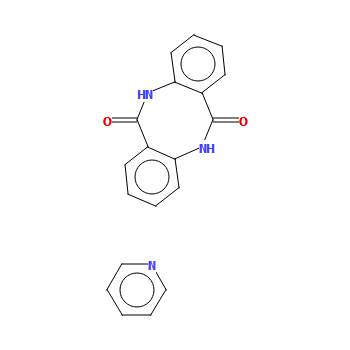

In [35]:
img